In [1]:
import os 
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import scgen
import seaborn as sns
from scipy import stats
import matplotlib
from scgen.file_utils import ensure_dir
sc.set_figure_params(dpi_save=300)

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2026-02-16 00:35:44.886352: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 00:35:44.983736: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH:

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
path_to_save = "../results/Figures/Supplemental Figure 12/"
ensure_dir(path_to_save)
sc.settings.figdir = path_to_save

In [3]:
pbmc = scgen.load_file("../data/train_pbmc.h5ad")
cd4t = pbmc[pbmc.obs["cell_type"] == "CD4T"]
pbmc

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 16893 × 6998
    obs: 'condition', 'n_counts', 'n_genes', 'mt_frac', 'cell_type'
    var: 'gene_symbol', 'n_cells'
    uns: 'cell_type_colors', 'condition_colors', 'neighbors'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'distances', 'connectivities'

In [4]:
pbmc.obs.groupby(['cell_type', 'condition']).size()

/tmp/ipykernel_71048/191267336.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pbmc.obs.groupby(['cell_type', 'condition']).size()


cell_type    condition 
CD4T         control       2437
             stimulated    3127
CD14+Mono    control       1946
             stimulated     615
B            control        818
             stimulated     993
CD8T         control        574
             stimulated     541
NK           control        517
             stimulated     646
FCGR3A+Mono  control       1100
             stimulated    2501
Dendritic    control        615
             stimulated     463
dtype: int64

In [5]:
sc.tl.rank_genes_groups(cd4t, groupby="condition", n_genes=100, method="wilcoxon")
diff_genes = cd4t.uns["rank_genes_groups"]["names"]["stimulated"]

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [6]:
%%bash
python ../code/vec_arith_pca.py

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2026-02-16 00:35:48.128626: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 00:35:48.231837: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH:

Reconstruction output already exists, skipping: ../data/reconstructed/PCAVecArithm/PCA_CD4T.h5ad
Reconstruction output already exists, skipping: ../data/reconstructed/PCAVecArithm/PCA_CD4T_biased.h5ad
Reconstruction output already exists, skipping: ../data/reconstructed/PCAVecArithm/PCA_pbmc.h5ad


In [7]:
pca_cd4t_biased = scgen.load_file("../data/reconstructed/PCAVecArithm/PCA_CD4T_biased.h5ad")
pca_cd4t_biased

AnnData object with n_obs × n_vars = 8001 × 6998
    obs: 'condition'

In [8]:
pca_cd4t_biased.obs.groupby(['condition']).size()

/tmp/ipykernel_71048/2664030759.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pca_cd4t_biased.obs.groupby(['condition']).size()


condition
ctrl         2437
pred_stim    2437
real_stim    3127
dtype: int64

In [9]:
pca_cd4t_unbiased = scgen.load_file("../data/reconstructed/PCAVecArithm/PCA_CD4T.h5ad")
pca_cd4t_unbiased

AnnData object with n_obs × n_vars = 8001 × 6998
    obs: 'condition'

In [10]:
pca_cd4t_unbiased.obs.groupby(['condition']).size()

/tmp/ipykernel_71048/754444917.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pca_cd4t_unbiased.obs.groupby(['condition']).size()


condition
ctrl         2437
pred_stim    2437
real_stim    3127
dtype: int64

0.726409943534304
0.8249493074407868


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


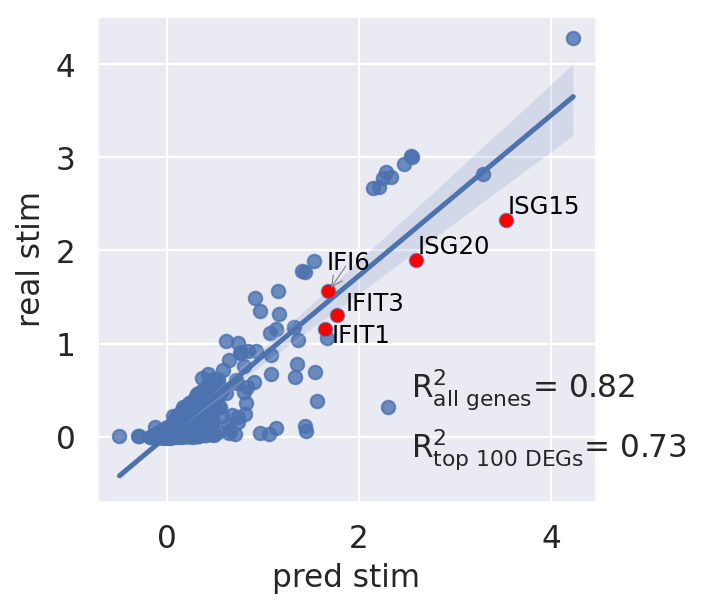

In [11]:
scgen.plotting.reg_mean_plot(pca_cd4t_biased,
                             labels={"x": "pred stim", "y": "real stim"},
                             condition_key="condition",
                             axis_keys={"x": "pred_stim", "y": "real_stim"},
                             path_to_save=os.path.join(path_to_save, "SupplFig12a_PCA_reg_mean.pdf"),
                             title="",
                             fontsize=14,
                             x_coeff=0.4,
                             y_coeff=0.9,
                             gene_list=diff_genes[:5],
                             legend=False,
                             show=True,
                             top_100_genes=diff_genes)

0.8103444712012633
0.8965860382286349


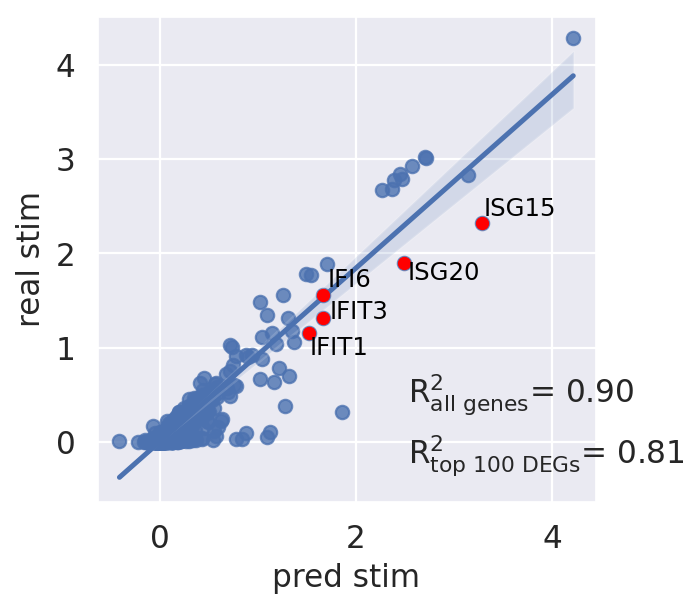

In [12]:
scgen.plotting.reg_mean_plot(pca_cd4t_unbiased,
                             labels={"x": "pred stim", "y": "real stim"},
                             condition_key="condition",
                             axis_keys={"x": "pred_stim", "y": "real_stim"},
                             path_to_save=os.path.join(path_to_save, "SupplFig12b_PCA_reg_mean.pdf"),
                             title="",
                             fontsize=14,
                             x_coeff=0.4,
                             y_coeff=0.9,
                             gene_list=diff_genes[:5],
                             legend=False,
                             show=True,
                             top_100_genes=diff_genes)

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 6998 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


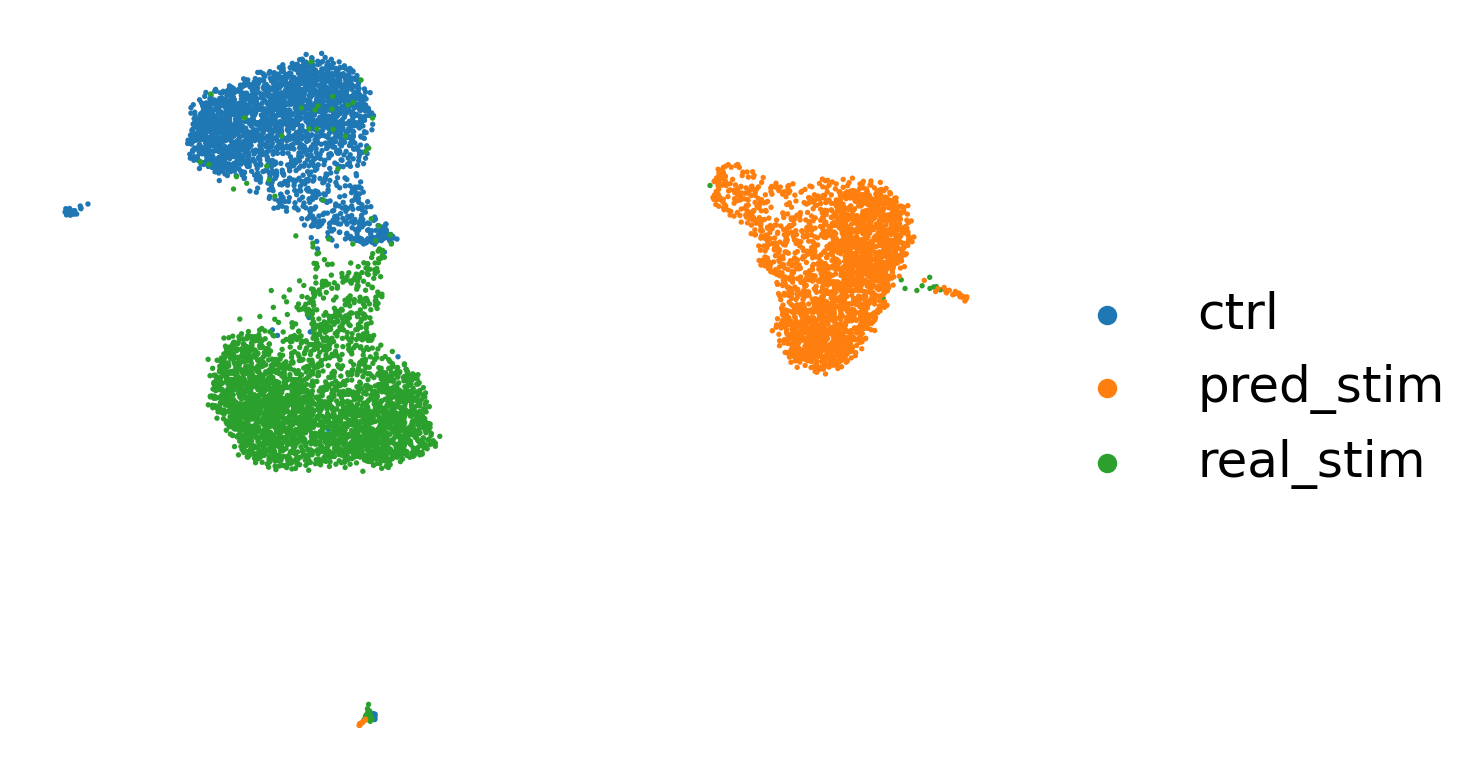

In [13]:
plt.style.use('default')
sc.pp.neighbors(pca_cd4t_biased)
sc.tl.umap(pca_cd4t_biased)
sc.pl.umap(pca_cd4t_biased, color=["condition"], frameon=False, palette=matplotlib.rcParams["axes.prop_cycle"],
           save="Vec_Arith_PCA_biased.png", show=True,
           legend_fontsize=18, title="")

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 6998 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


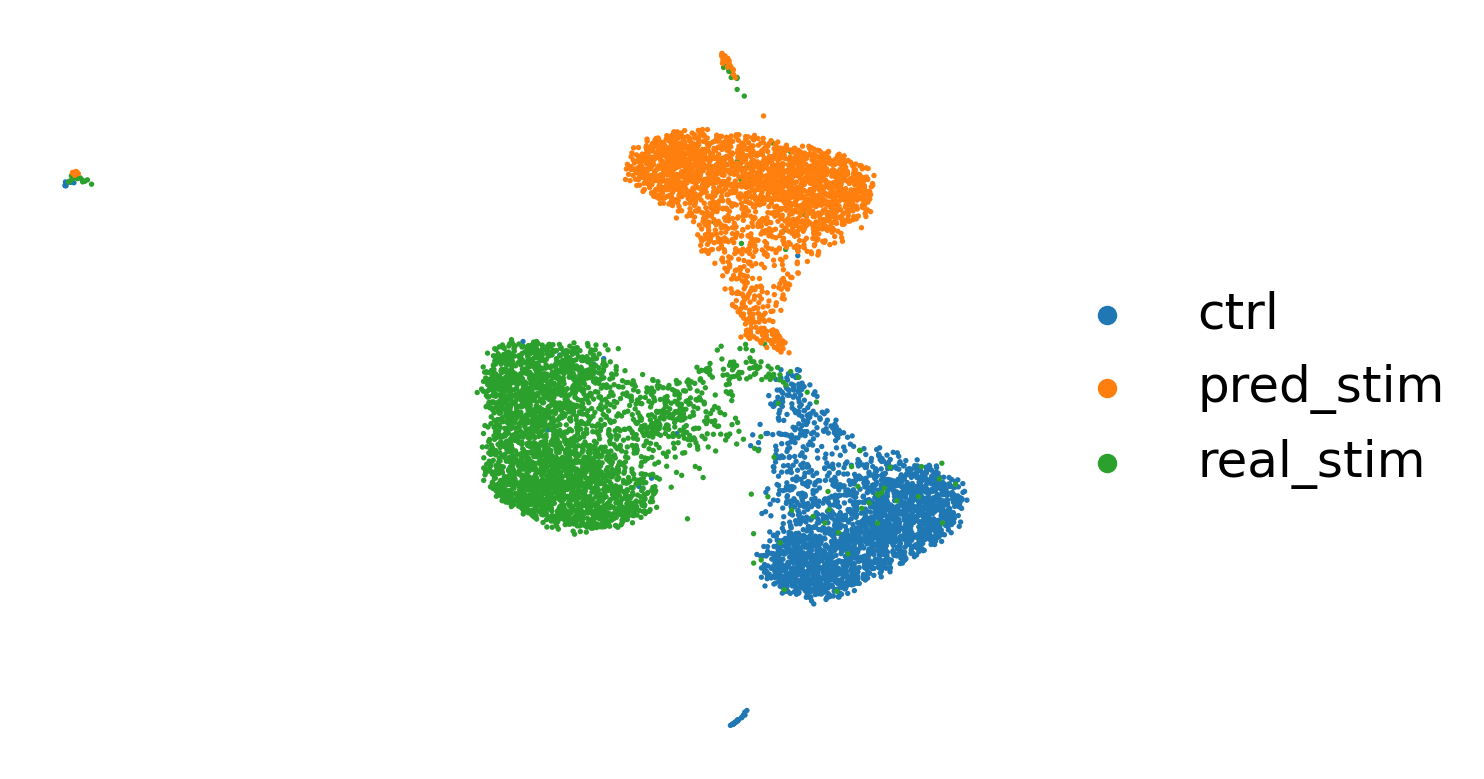

In [14]:
sc.pp.neighbors(pca_cd4t_unbiased)
sc.tl.umap(pca_cd4t_unbiased)
sc.pl.umap(pca_cd4t_unbiased, color=["condition"], frameon=False, palette=matplotlib.rcParams["axes.prop_cycle"],
           save="Vec_Arith_PCA_unbiased.png", show=True,
           legend_fontsize=18, title="")